In [1]:
# Upgrading pip to the latest version
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Install required Libraries 
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import Required Libraries
from pathlib import Path
import pickle

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

from src.db_utils import load_data_to_sqlite, load_raw_data
from src.feature_eng import (
    add_calendar_features,
    add_lag_features,
    add_markdown_features,
    apply_iqr_filter,
    build_model_matrix,
    clean_walmart_data,
    merge_walmart_data,
)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [4]:
# Project Paths
PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
DATABASE_DIR = PROJECT_ROOT / 'data' / 'database'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = MODELS_DIR / 'figures'

DATABASE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'Weekly_Sales'
RAW_DIR

WindowsPath('d:/Projects/Sales & Demand Intelligence forecasting/sales-intelligence/data/raw')

In [5]:
# Dataset Loading
train_raw, future_raw, features_raw, stores_raw = load_raw_data()

overview = pd.DataFrame({
    'dataset': ['train', 'test/future', 'features', 'stores'],
    'rows': [len(train_raw), len(future_raw), len(features_raw), len(stores_raw)],
    'columns': [train_raw.shape[1], future_raw.shape[1], features_raw.shape[1], stores_raw.shape[1]],
})
display(overview)
display(train_raw.head())
display(future_raw.head())
display(features_raw.head())
display(stores_raw.head())

,dataset,rows,columns
0,train,421570,5
1,test/future,115064,4
2,features,8190,12
3,stores,45,3


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
# EDA On Raw Data
print('Train date range:', train_raw['Date'].min(), 'to', train_raw['Date'].max())
print('Future/test date range:', future_raw['Date'].min(), 'to', future_raw['Date'].max())
print('Stores:', train_raw['Store'].nunique())
print('Departments:', train_raw['Dept'].nunique())
print('Duplicate train keys:', train_raw.duplicated(['Store', 'Dept', 'Date']).sum())
print('Negative sales rows:', (train_raw[TARGET] < 0).sum())
print('Zero sales rows:', (train_raw[TARGET] == 0).sum())

display(train_raw[TARGET].describe())
display(features_raw.isna().sum().to_frame('missing_values'))

Train date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Future/test date range: 2012-11-02 00:00:00 to 2013-07-26 00:00:00
Stores: 45
Departments: 81
Duplicate train keys: 0
Negative sales rows: 1285
Zero sales rows: 73


count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

,missing_values
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


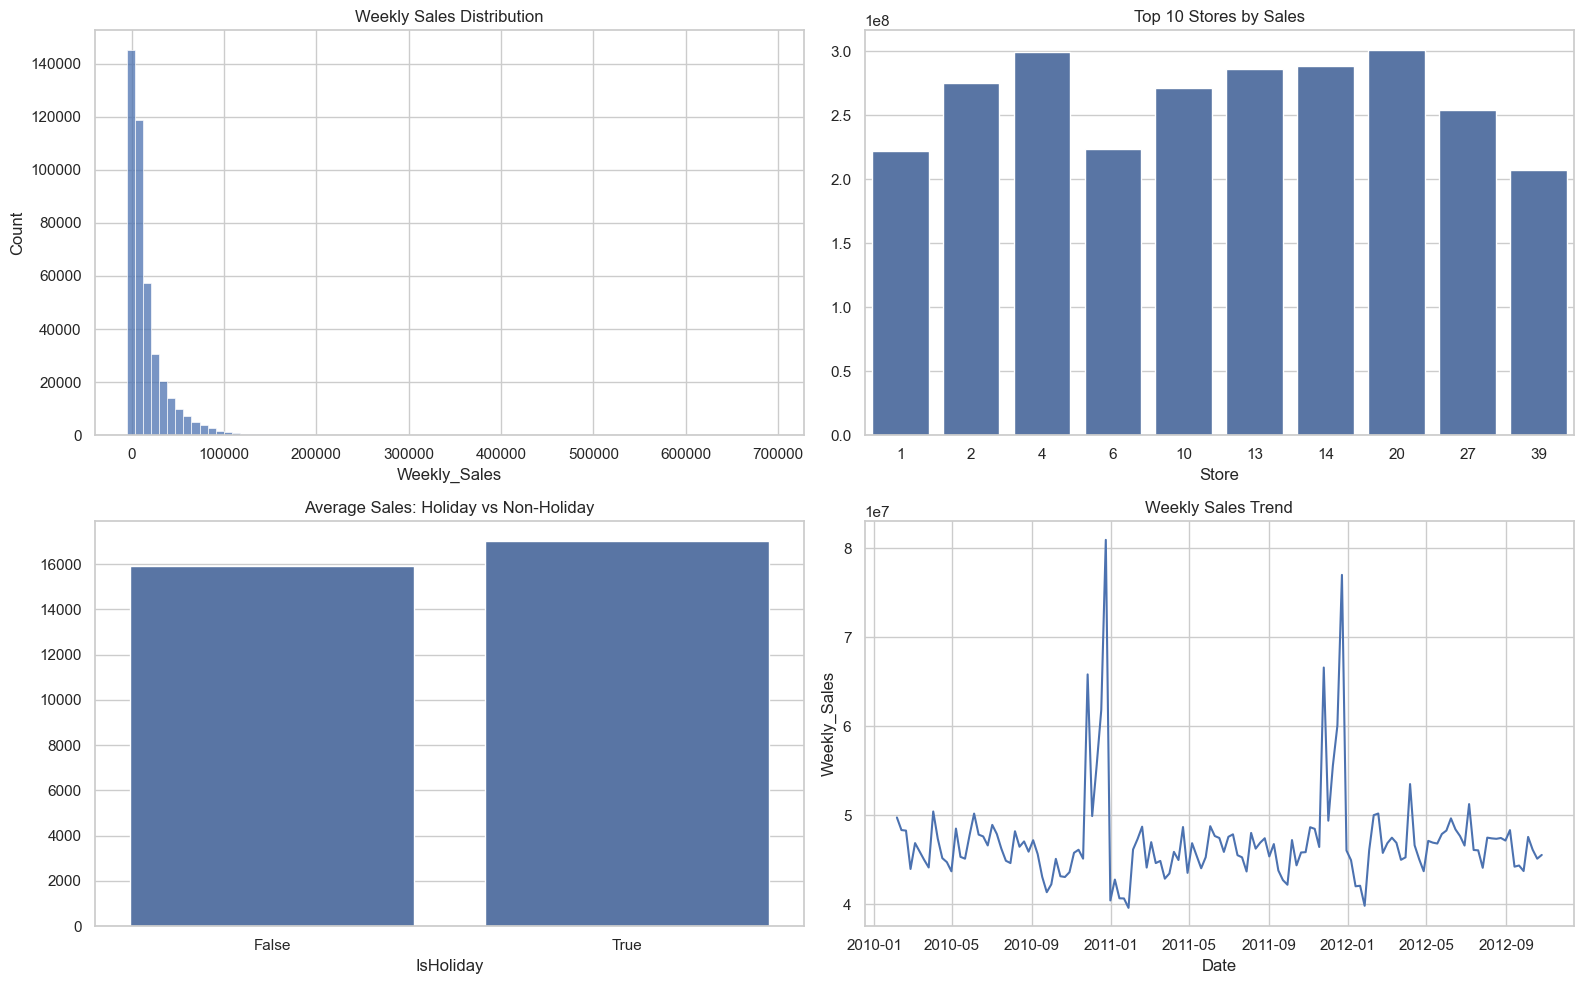

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(train_raw[TARGET], bins=80, ax=axes[0, 0])
axes[0, 0].set_title('Weekly Sales Distribution')

top_stores = train_raw.groupby('Store')[TARGET].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_stores.index, y=top_stores.values, ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Stores by Sales')

holiday_sales = train_raw.groupby('IsHoliday')[TARGET].mean()
sns.barplot(x=holiday_sales.index.astype(str), y=holiday_sales.values, ax=axes[1, 0])
axes[1, 0].set_title('Average Sales: Holiday vs Non-Holiday')

weekly_trend = train_raw.groupby('Date')[TARGET].sum().reset_index()
sns.lineplot(data=weekly_trend, x='Date', y=TARGET, ax=axes[1, 1])
axes[1, 1].set_title('Weekly Sales Trend')

plt.tight_layout()
plt.show()

In [8]:
# Data Cleaning and Preprocessing
master = merge_walmart_data(train_raw, features_raw, stores_raw)

print('Missing values before cleaning:')
display(master.isna().sum().to_frame('missing_before'))

master, impute_values, type_mode = clean_walmart_data(master, remove_negative_sales=True)

print('Missing values after cleaning:')
display(master.isna().sum().to_frame('missing_after'))
print('Numeric mean imputation values:', impute_values)
print('Type mode:', type_mode)
master.head()

Missing values before cleaning:


,missing_before
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


Missing values after cleaning:


,missing_after
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


Numeric mean imputation values: {'MarkDown1': 5347.45, 'MarkDown2': 203.26, 'MarkDown3': 24.73, 'MarkDown4': 1481.31, 'MarkDown5': 3359.45}
Type mode: A


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,5347.45,203.26,24.73,1481.31,3359.45,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,1,38.51,2.548,5347.45,203.26,24.73,1481.31,3359.45,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,5347.45,203.26,24.73,1481.31,3359.45,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,0,46.63,2.561,5347.45,203.26,24.73,1481.31,3359.45,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,0,46.50,2.625,5347.45,203.26,24.73,1481.31,3359.45,211.350143,8.106,A,151315


### Markdown Columns Matter
The `MarkDown1` to `MarkDown5` columns represent promotional discount amounts used by the stores. They show how much markdown activity was applied in a given week, so they are useful for explaining how promotions can influence weekly sales and monthly demand trends.

In [9]:
# Feature Engineering
model_data = add_calendar_features(master)
model_data = add_markdown_features(model_data)
model_data = add_lag_features(model_data)

print('Model data shape:', model_data.shape)
display(model_data.head())

Model data shape: (420285, 34)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,ISO_Week_Number,Quarter,Day_Of_Month,Season,Total_Markdown_Amount,Has_Markdown_Flag,Sales_Lag_1_Weeks,Sales_Lag_4_Weeks,Sales_Lag_8_Weeks,Sales_Lag_13_Weeks,Sales_Lag_52_Weeks,Sales_Rolling_Mean_4_Weeks,Sales_Rolling_Std_4_Weeks,Sales_Rolling_Mean_8_Weeks,Sales_Rolling_Std_8_Weeks,Sales_Rolling_Mean_13_Weeks
0,1,1,2010-02-05,24924.50,0,42.31,2.572,5347.45,203.26,24.73,1481.31,3359.45,211.096358,8.106,A,151315,2010,2,5,1,5,Winter,10416.2,1,7659.09,7659.09,7659.09,7659.09,7659.09,7788.786250,760.104434,7856.687500,988.229384,7921.198077
1,1,1,2010-02-12,46039.49,1,38.51,2.548,5347.45,203.26,24.73,1481.31,3359.45,211.242170,8.106,A,151315,2010,2,6,1,12,Winter,10416.2,1,24924.50,7659.09,7659.09,7659.09,7659.09,24924.500000,760.104434,24924.500000,988.229384,24924.500000
2,1,1,2010-02-19,41595.55,0,39.93,2.514,5347.45,203.26,24.73,1481.31,3359.45,211.289143,8.106,A,151315,2010,2,7,1,19,Winter,10416.2,1,46039.49,7659.09,7659.09,7659.09,7659.09,35481.995000,14930.552614,35481.995000,14930.552614,35481.995000
3,1,1,2010-02-26,19403.54,0,46.63,2.561,5347.45,203.26,24.73,1481.31,3359.45,211.319643,8.106,A,151315,2010,2,8,1,26,Winter,10416.2,1,41595.55,7659.09,7659.09,7659.09,7659.09,37519.846667,11131.900957,37519.846667,11131.900957,37519.846667
4,1,1,2010-03-05,21827.90,0,46.50,2.625,5347.45,203.26,24.73,1481.31,3359.45,211.350143,8.106,A,151315,2010,3,9,1,5,Spring,10416.2,1,19403.54,24924.50,7659.09,7659.09,7659.09,32990.770000,12832.106391,32990.770000,12832.106391,32990.770000


## 8. Outlier Detection And Removal

In [10]:
def split_by_time(df):
    dates = np.array(sorted(df['Date'].unique()))
    train_end = int(len(dates) * 0.70)
    valid_end = int(len(dates) * 0.85)
    train_dates = dates[:train_end]
    valid_dates = dates[train_end:valid_end]
    test_dates = dates[valid_end:]
    return (
        df[df['Date'].isin(train_dates)].copy(),
        df[df['Date'].isin(valid_dates)].copy(),
        df[df['Date'].isin(test_dates)].copy(),
    )

## 8. Outlier Detection And Removal

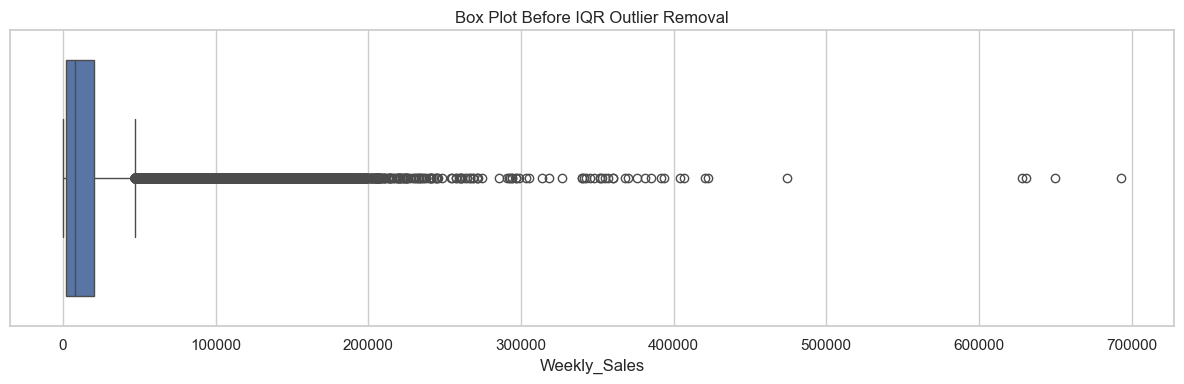

{'q1': 2117.56, 'q3': 20268.38, 'iqr': 18150.82, 'lower': -25108.67, 'upper': 47494.61, 'removed_rows': 35381}


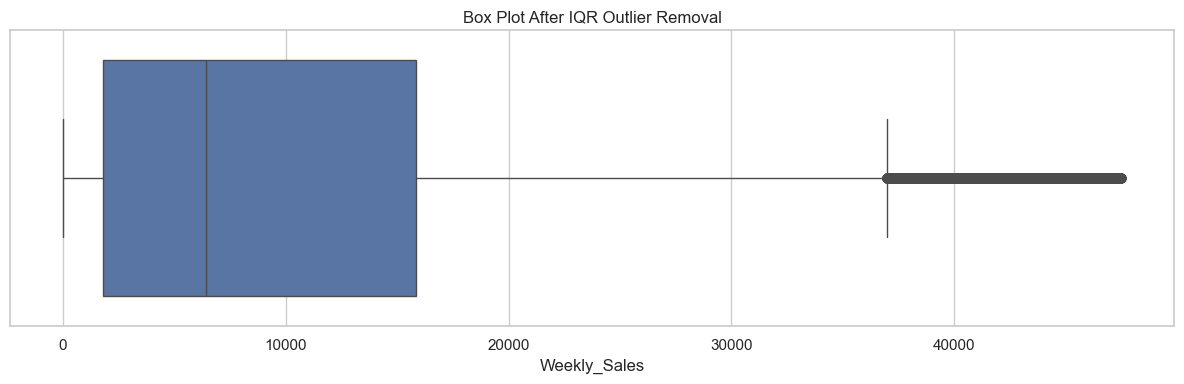

In [11]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=model_data[TARGET])
plt.title('Box Plot Before IQR Outlier Removal')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'boxplot_before_outlier_removal.png', dpi=150)
plt.show()

model_data_iqr, iqr_bounds = apply_iqr_filter(model_data)
print(iqr_bounds)

plt.figure(figsize=(12, 4))
sns.boxplot(x=model_data_iqr[TARGET])
plt.title('Box Plot After IQR Outlier Removal')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'boxplot_after_outlier_removal.png', dpi=150)
plt.show()

## 9. EDA After Cleaning And Outlier Removal

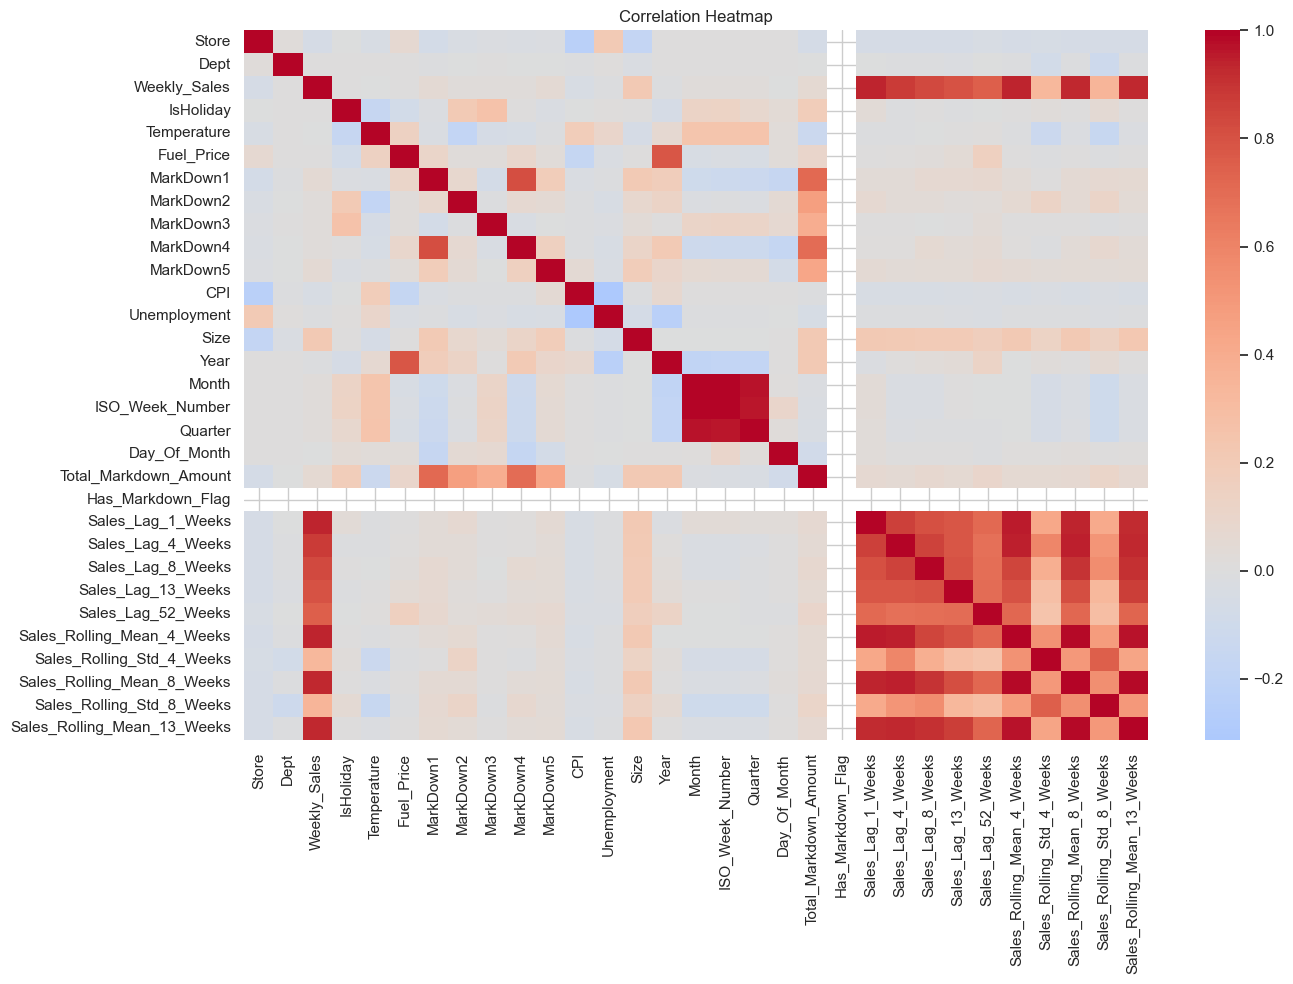

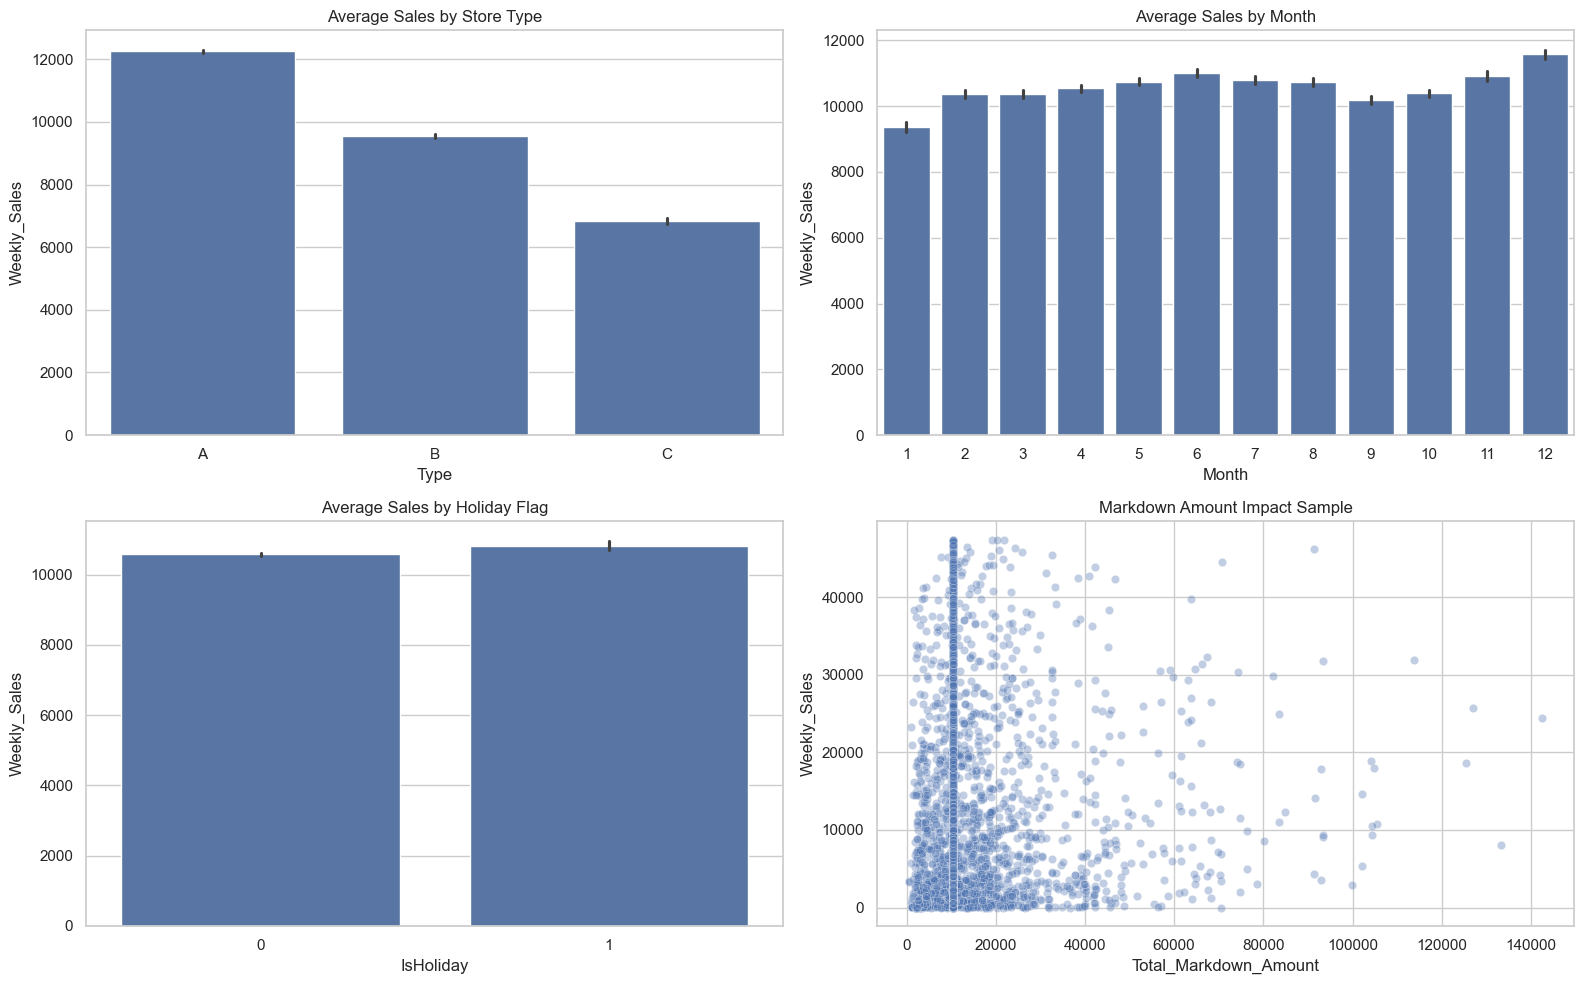

In [12]:
numeric_cols = model_data_iqr.select_dtypes(include=np.number).columns
corr = model_data_iqr[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(data=model_data_iqr, x='Type', y=TARGET, estimator='mean', ax=axes[0, 0])
axes[0, 0].set_title('Average Sales by Store Type')
sns.barplot(data=model_data_iqr, x='Month', y=TARGET, estimator='mean', ax=axes[0, 1])
axes[0, 1].set_title('Average Sales by Month')
sns.barplot(data=model_data_iqr, x='IsHoliday', y=TARGET, estimator='mean', ax=axes[1, 0])
axes[1, 0].set_title('Average Sales by Holiday Flag')
sns.scatterplot(data=model_data_iqr.sample(min(5000, len(model_data_iqr)), random_state=42), x='Total_Markdown_Amount', y=TARGET, alpha=0.35, ax=axes[1, 1])
axes[1, 1].set_title('Markdown Amount Impact Sample')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_subplots.png', dpi=150)
plt.show()

## 10. Dataset Splitting

In [13]:
train_df, valid_df, test_df = split_by_time(model_data_iqr)
train_iqr_df = train_df.copy()

X_train, y_train, feature_names = build_model_matrix(train_iqr_df, TARGET)
X_valid, y_valid, _ = build_model_matrix(valid_df, TARGET, feature_names)
X_test, y_test, _ = build_model_matrix(test_df, TARGET, feature_names)

print(X_train.shape, X_valid.shape, X_test.shape)
display(pd.Series(feature_names).to_frame('model_features').head(30))

(268434, 37) (57029, 37) (59441, 37)


,model_features
0,Store
1,Dept
2,IsHoliday
3,Temperature
4,Fuel_Price
5,MarkDown1
6,MarkDown2
7,MarkDown3
8,MarkDown4
9,MarkDown5


## 12. Model Training And Evaluation Functions

In [14]:
def weighted_mae(y_true, y_pred, holidays=None):
    weights = np.ones(len(y_true)) if holidays is None else np.where(holidays.astype(int).to_numpy() == 1, 5, 1)
    return np.sum(weights * np.abs(y_true.to_numpy() - y_pred)) / np.sum(weights)

def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true.to_numpy()))
    return 0 if denominator == 0 else np.sum(np.abs(y_true.to_numpy() - y_pred)) / denominator

def regression_metrics(name, y_true, y_pred, holidays=None):
    wape_value = wape(y_true, y_pred)
    return {
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': r2_score(y_true, y_pred),
        'WMAE': weighted_mae(y_true, y_pred, holidays),
        'WAPE': wape_value,
        'Forecast_Accuracy_%': max(0, 100 * (1 - wape_value)),
    }

In [15]:
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=80, max_depth=16, min_samples_leaf=3, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=450, max_depth=7, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, objective='reg:squarederror', random_state=42, n_jobs=-1),
}

metric_rows = []
trained_models = {}

baseline_pred = X_valid['Sales_Rolling_Mean_4_Weeks'].to_numpy()
metric_rows.append(regression_metrics('Rolling Mean Baseline', y_valid, baseline_pred, valid_df['IsHoliday']))

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    metric_rows.append(regression_metrics(name, y_valid, pred, valid_df['IsHoliday']))
    trained_models[name] = model

metrics_df = pd.DataFrame(metric_rows).sort_values('WMAE')
metrics_df.to_csv(MODELS_DIR / 'model_metrics.csv', index=False)
display(metrics_df)

Training Ridge Regression...
Training Random Forest...
Training XGBoost...


,model,MAE,RMSE,R2,WMAE,WAPE,Forecast_Accuracy_%
3,XGBoost,1065.543520,2013.677474,0.967533,1059.465807,0.103804,89.619570
2,Random Forest,1096.033934,2121.171194,0.963974,1099.379151,0.106775,89.322536
1,Ridge Regression,1422.962257,2669.085725,0.942958,1559.950303,0.138624,86.137629
0,Rolling Mean Baseline,1941.419442,5203.707736,0.783182,1940.648617,0.189131,81.086866


## 13. Time-Series Cross Validation For XGBoost

In [16]:
tscv_data = pd.concat([train_iqr_df, valid_df]).sort_values('Date')
X_cv, y_cv, _ = build_model_matrix(tscv_data, TARGET, feature_names)
tscv = TimeSeriesSplit(n_splits=3)
cv_rows = []

for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_cv), start=1):
    cv_model = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.06, subsample=0.85, colsample_bytree=0.85, objective='reg:squarederror', random_state=42, n_jobs=-1)
    cv_model.fit(X_cv.iloc[train_idx], y_cv.iloc[train_idx])
    cv_pred = cv_model.predict(X_cv.iloc[valid_idx])
    cv_rows.append(regression_metrics(f'Fold {fold}', y_cv.iloc[valid_idx], cv_pred))

cv_metrics = pd.DataFrame(cv_rows)
display(cv_metrics)

,model,MAE,RMSE,R2,WMAE,WAPE,Forecast_Accuracy_%
0,Fold 1,1883.214903,3459.526935,0.904415,1883.214903,0.179676,82.032371
1,Fold 2,1010.535935,1873.384352,0.972892,1010.535935,0.095693,90.430710
2,Fold 3,1166.739157,2108.838837,0.965534,1166.739157,0.110658,88.934172


## 14. Select Final Model And Test Performance

,model,MAE,RMSE,R2,WMAE,WAPE,Forecast_Accuracy_%
0,XGBoost Final Test,879.234997,1583.584635,0.980926,901.365432,0.083028,91.697212


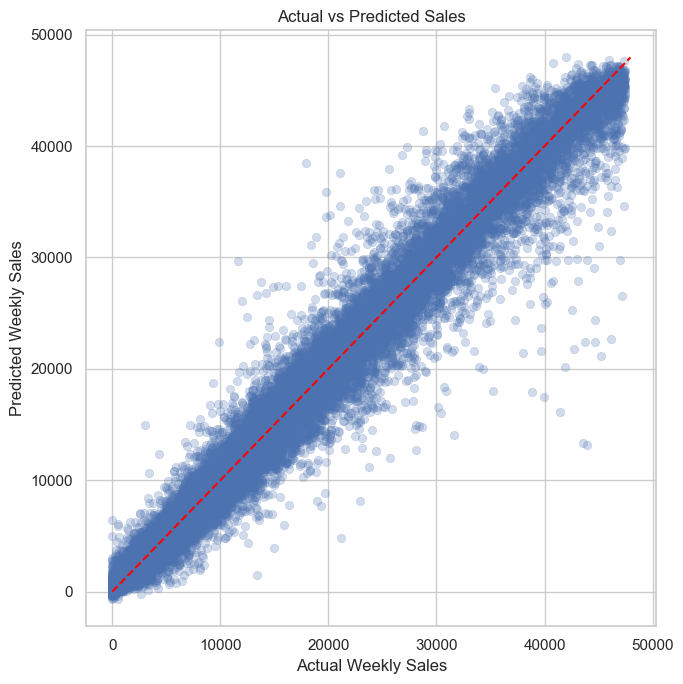

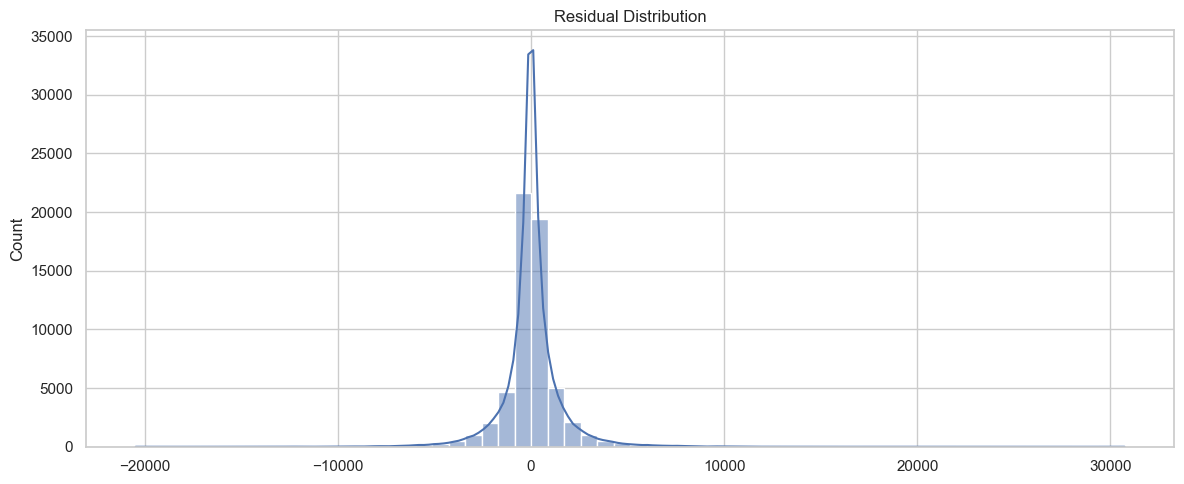

In [17]:
# XGBoost is the official final model for this project because it supports strong tabular forecasting and SHAP explainability.
best_model_name = 'XGBoost'
best_model = trained_models[best_model_name]
test_pred = best_model.predict(X_test)

final_metrics = regression_metrics(f'{best_model_name} Final Test', y_test, test_pred, test_df['IsHoliday'])
final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv(MODELS_DIR / 'final_test_metrics.csv', index=False)
display(final_metrics_df)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=test_pred, alpha=0.25, edgecolor=None)
limit = max(float(y_test.max()), float(np.max(test_pred)))
plt.plot([0, limit], [0, limit], color='red', linestyle='--')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Sales')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'actual_vs_predicted.png', dpi=150)
plt.show()

residuals = y_test.to_numpy() - test_pred
plt.figure(figsize=(12, 5))
sns.histplot(residuals, bins=60, kde=True)
plt.title('Residual Distribution')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'residual_distribution.png', dpi=150)
plt.show()

## 15. Model Comparison Visual

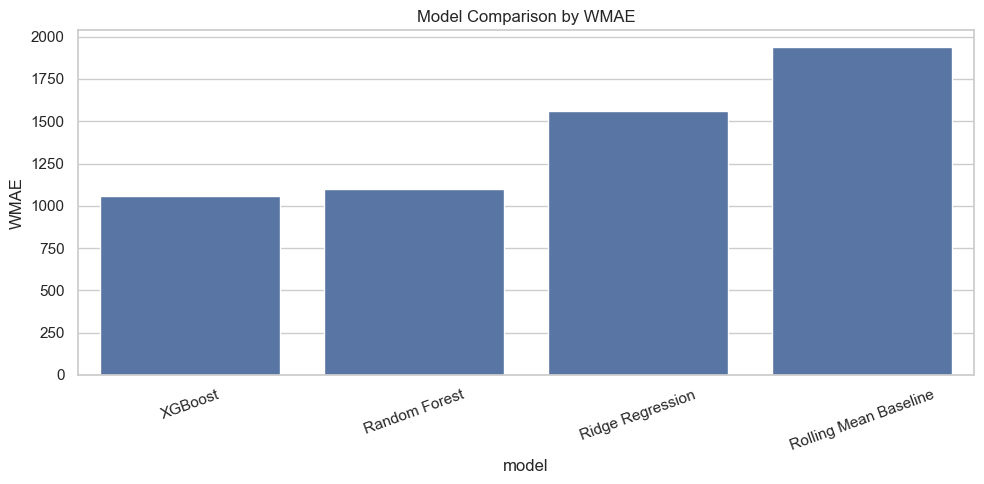

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='model', y='WMAE')
plt.title('Model Comparison by WMAE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_wmae.png', dpi=150)
plt.show()

## 16. SHAP Explainability

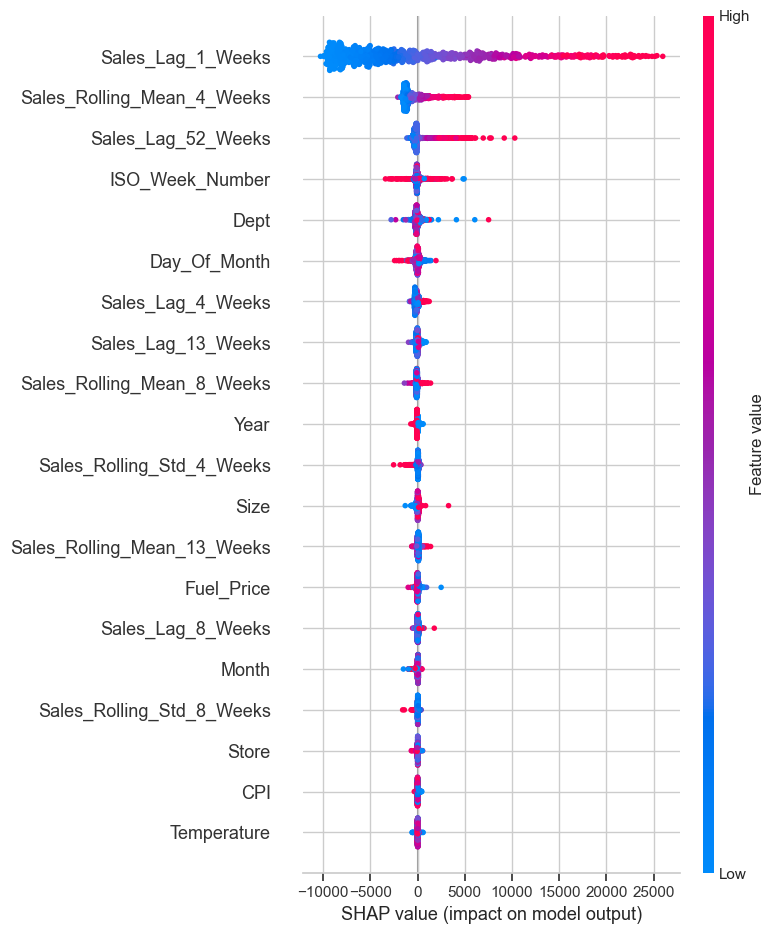

In [20]:
import shap

shap_sample = X_train.sample(min(1000, len(X_train)), random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(shap_sample, check_additivity=False)

shap.summary_plot(shap_values, shap_sample, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=150)
plt.show()

with open(MODELS_DIR / 'shap_explainer.pkl', 'wb') as file:
    pickle.dump(explainer, file)

## 17. Classification Metrics Add-On

The main model is regression. This add-on creates a `High_Demand_Flag` so classification metrics are used correctly.

Accuracy: 0.9718388889863052
Precision: 0.9514381770638775
Recall: 0.9301731064202761
F1: 0.9406854779140198
AUC: 0.995919460641354

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     43338
           1       0.95      0.93      0.94     13691

    accuracy                           0.97     57029
   macro avg       0.96      0.96      0.96     57029
weighted avg       0.97      0.97      0.97     57029



,Pred Low/Normal,Pred High
Actual Low/Normal,42688,650
Actual High,956,12735


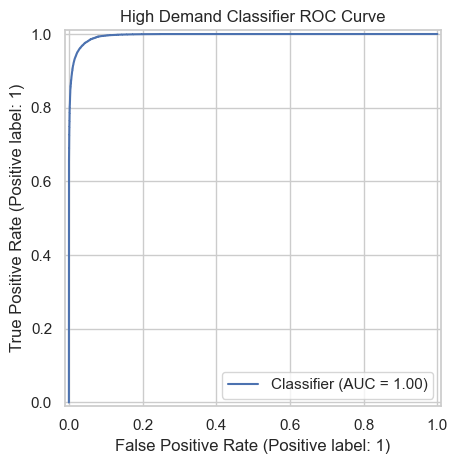

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier

threshold = train_iqr_df[TARGET].quantile(0.75)
y_train_cls = (y_train >= threshold).astype(int)
y_valid_cls = (y_valid >= threshold).astype(int)

classifier = XGBClassifier(n_estimators=250, max_depth=5, learning_rate=0.06, subsample=0.85, colsample_bytree=0.85, eval_metric='logloss', random_state=42, n_jobs=-1)
classifier.fit(X_train, y_train_cls)
cls_pred = classifier.predict(X_valid)
cls_proba = classifier.predict_proba(X_valid)[:, 1]

print('Accuracy:', accuracy_score(y_valid_cls, cls_pred))
print('Precision:', precision_score(y_valid_cls, cls_pred))
print('Recall:', recall_score(y_valid_cls, cls_pred))
print('F1:', f1_score(y_valid_cls, cls_pred))
print('AUC:', roc_auc_score(y_valid_cls, cls_proba))
print('\nClassification Report:\n', classification_report(y_valid_cls, cls_pred))
display(pd.DataFrame(confusion_matrix(y_valid_cls, cls_pred), index=['Actual Low/Normal', 'Actual High'], columns=['Pred Low/Normal', 'Pred High']))

RocCurveDisplay.from_predictions(y_valid_cls, cls_proba)
plt.title('High Demand Classifier ROC Curve')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'high_demand_roc_curve.png', dpi=150)
plt.show()

## 18. Monthly Demand Forecast

,Store,Dept,Month,Actual_Monthly_Demand,Predicted_Monthly_Demand,Monthly_Difference
0,1,1,2012-06,83646.54,85764.117188,-2117.577188
1,1,1,2012-07,66468.79,67101.406250,-632.616250
2,1,1,2012-08,83045.57,80179.960938,2865.609063
3,1,1,2012-09,76137.90,77501.468750,-1363.568750
4,1,1,2012-10,96244.56,100465.484375,-4220.924375


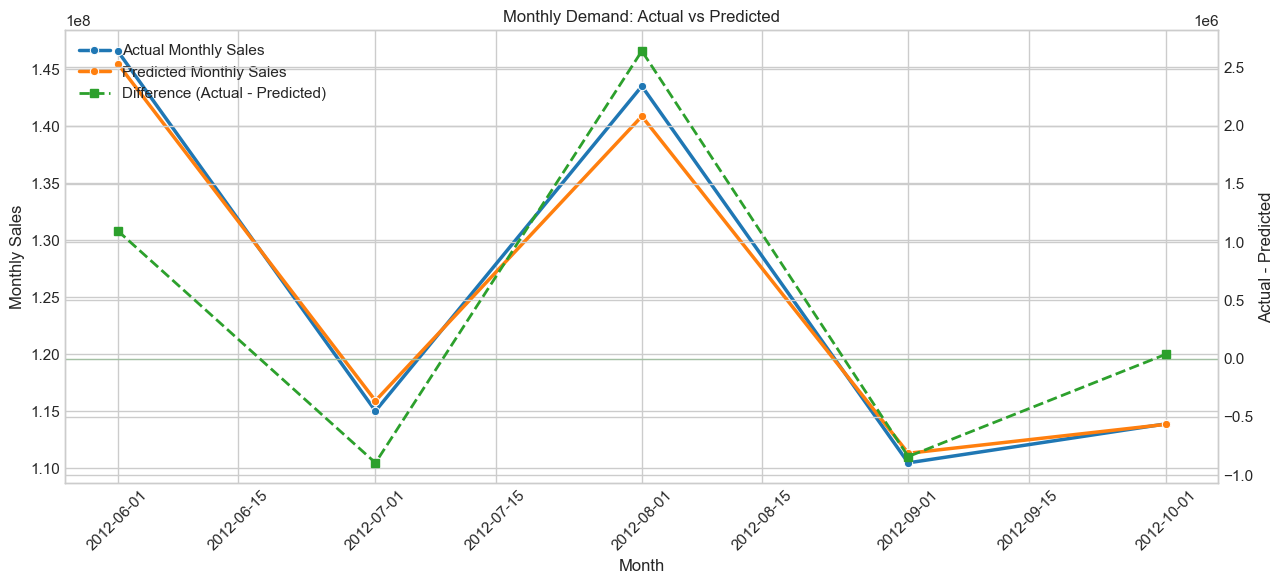

In [26]:
monthly_forecast = test_df[['Store', 'Dept', 'Date']].copy()
monthly_forecast['Actual_Weekly_Sales'] = y_test.to_numpy()
monthly_forecast['Predicted_Weekly_Sales'] = test_pred
monthly_forecast['Month'] = monthly_forecast['Date'].dt.to_period('M').astype(str)
monthly_forecast = (
    monthly_forecast.groupby(['Store', 'Dept', 'Month'], as_index=False)
    .agg(
        Actual_Monthly_Demand=('Actual_Weekly_Sales', 'sum'),
        Predicted_Monthly_Demand=('Predicted_Weekly_Sales', 'sum'),
    )
    .sort_values(['Store', 'Dept', 'Month'])
)
monthly_forecast['Monthly_Difference'] = monthly_forecast['Actual_Monthly_Demand'] - monthly_forecast['Predicted_Monthly_Demand']
monthly_forecast.to_csv(MODELS_DIR / 'monthly_demand_forecast.csv', index=False)
display(monthly_forecast.head())

monthly_trend = (
    monthly_forecast.assign(Month_Date=pd.to_datetime(monthly_forecast['Month'], format='%Y-%m'))
    .groupby('Month_Date', as_index=False)[['Actual_Monthly_Demand', 'Predicted_Monthly_Demand', 'Monthly_Difference']]
    .sum()
    .sort_values('Month_Date')
)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(13, 6))
sns.lineplot(data=monthly_trend, x='Month_Date', y='Actual_Monthly_Demand', marker='o', linewidth=2.5, label='Actual Monthly Sales', ax=ax1, color='#1f77b4')
sns.lineplot(data=monthly_trend, x='Month_Date', y='Predicted_Monthly_Demand', marker='o', linewidth=2.5, label='Predicted Monthly Sales', ax=ax1, color='#ff7f0e')
ax1.set_title('Monthly Demand: Actual vs Predicted')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Sales')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(monthly_trend['Month_Date'], monthly_trend['Monthly_Difference'], marker='s', linestyle='--', linewidth=2, color='#2ca02c', label='Difference (Actual - Predicted)')
ax2.axhline(0, color='#2ca02c', alpha=0.25, linewidth=1)
ax2.set_ylabel('Actual - Predicted')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'monthly_demand_trend.png', dpi=150)
plt.show()

## 19. Save Final Artifacts

In [23]:
feature_defaults = X_train.median(numeric_only=True).to_dict()
metadata = {
    'feature_names': feature_names,
    'feature_defaults': feature_defaults,
    'impute_values': impute_values,
    'type_mode': type_mode,
    'iqr_bounds': iqr_bounds,
    'best_model_name': best_model_name,
    'target': TARGET,
    'train_date_range': (str(train_df['Date'].min().date()), str(train_df['Date'].max().date())),
    'validation_date_range': (str(valid_df['Date'].min().date()), str(valid_df['Date'].max().date())),
    'test_date_range': (str(test_df['Date'].min().date()), str(test_df['Date'].max().date())),
}

joblib.dump(best_model, MODELS_DIR / 'xgb_demand_model.pkl')
joblib.dump(metadata, MODELS_DIR / 'model_features.pkl')
load_data_to_sqlite()

print('Saved model artifacts in:', MODELS_DIR)
print('Notebook training workflow complete.')

sales table:        421,570 rows loaded
future_sales table: 115,064 rows loaded
features table:     8,190 rows loaded
stores table:       45 rows loaded
Database created:   D:\Projects\Sales & Demand Intelligence forecasting\sales-intelligence\data\database\inventory.db
Saved model artifacts in: d:\Projects\Sales & Demand Intelligence forecasting\sales-intelligence\models
Notebook training workflow complete.
